In [4]:
pip install xgboost

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 94.9/94.9 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 322.5/322.5 MB 3.3 MB/s eta 0:00:00


In [5]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.metrics import mean_absolute_percentage_error, r2_score, mean_squared_error
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from xgboost import XGBRegressor
from sklearn.svm import SVR
import matplotlib.pyplot as plt
import seaborn as sns

In [6]:
# Загрузка данных
data = pd.read_csv('/content/dataset_for_IC50_854.csv')

# Разделение на признаки и целевую переменную
X = data.drop('IC50, mM', axis=1)
y = data['IC50, mM']

# Разделение на обучающую и тестовую выборки
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Бдуем использовать модели Random Forest, Gradient Boosting, XGBoost, SVR с подбором гиперпараметров, в качестве скоринга применим r2

In [7]:
results = {}

In [8]:
# Random Forest
model_rf = RandomForestRegressor(n_estimators=50, random_state=42)

# Создаем пайплайн
pipe_rf = Pipeline([
    ('scaler', StandardScaler()),
    ('rf', model_rf)
])

params_rf = {
    'rf__n_estimators': [10, 30, 50],
    'rf__max_depth': [30, 40, 50],
    'rf__bootstrap': [True, False]
}

grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring='r2')

grid_rf.fit(X_train, y_train)
y_pred_rf = grid_rf.best_estimator_.predict(X_test)
results['Random Forest'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_rf),
    'R2': r2_score(y_test, y_pred_rf),
    'MSE': mean_squared_error(y_test, y_pred_rf)
}


In [9]:
# Gradient Boosting
model_gb = GradientBoostingRegressor(random_state=42)

# Создаем пайплайн
pipe_gb = Pipeline([
    ('scaler', StandardScaler()),
    ('gb', model_gb)
])

params_gb = {
    'gb__n_estimators': [250, 300, 350],
    'gb__learning_rate': [0.05, 0.1, 0.2]
}

grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring='r2')
grid_gb.fit(X_train, y_train)
y_pred_gb = grid_gb.best_estimator_.predict(X_test)
results['Gradient Boosting'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_gb),
    'R2': r2_score(y_test, y_pred_gb),
    'MSE': mean_squared_error(y_test, y_pred_gb)
}


In [11]:
# XGBoost
model_xgb = XGBRegressor(random_state=42, eval_metric='logloss')

# Создаем пайплайн
pipe_xgb = Pipeline([
    ('scaler', StandardScaler()),
    ('xgb', model_xgb)
])

params_xgb = {
    'xgb__n_estimators': [150, 200, 250],
    'xgb__learning_rate': [0.05, 0.1, 0.2]
}

grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring='r2')

grid_xgb.fit(X_train, y_train)
y_pred_xgb = grid_xgb.best_estimator_.predict(X_test)
results['XGBoost'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_xgb),
    'R2': r2_score(y_test, y_pred_xgb),
    'MSE': mean_squared_error(y_test, y_pred_xgb)
}



In [12]:
#SVR
pipe_svr = Pipeline([
    ('scaler', StandardScaler()),
    ('svr', SVR()),
])

params_svr = {
    'svr__C': [40, 50, 100],
    'svr__epsilon': [0.005, 0.01, 0.05],
}
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring='r2')

grid_svr.fit(X_train, y_train)
y_pred_svr = grid_svr.best_estimator_.predict(X_test)
results['SVR'] = {
    'MAPE': mean_absolute_percentage_error(y_test, y_pred_svr),
    'R2': r2_score(y_test, y_pred_svr),
    'MSE': mean_squared_error(y_test, y_pred_svr)
}

In [13]:
print(f"{'Model':<20} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<20} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")


Model                | MAPE     | R2     | MSE     
Random Forest        | 11.1587 | 0.0885 | 9793.8543
Gradient Boosting    | 14.6298 | 0.0060 | 10680.4055
XGBoost              | 11.6592 | 0.0040 | 10702.5942
SVR                  | 6.8800 | 0.1883 | 8722.2227


У моделей получилось неудовлетворительные метрики.

# Обучение на прологарифмированных данных

Так как при подготовке EDA мы предположили, что распределение исходных данных по таргетному признаку IC50 является лог-нормальным и обучение на обработанных "исходных" данных дает неудовлетворительные результаты, проверим распределение на прологарифмированных данных по таргетному признаку.

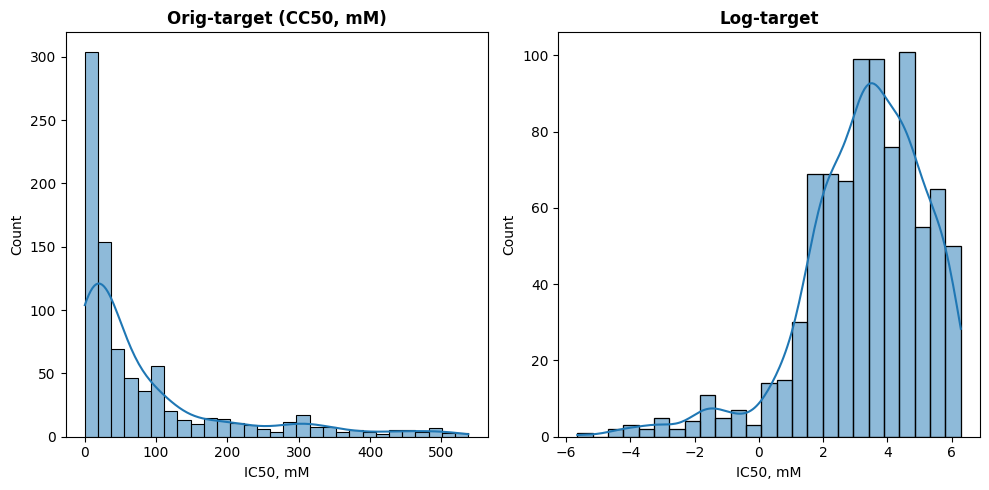

In [14]:
y_log = np.log(y + 1e-10)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
sns.histplot(y, kde=True, ax=axes[0])
axes[0].set_title('Orig-target (CC50, mM)', fontweight='bold')
sns.histplot(y_log, kde=True, ax=axes[1])
axes[1].set_title('Log-target', fontweight='bold')

plt.tight_layout()
plt.show()

Так как логарифм-таргет выглядит лучше, попробуем провести обучение на нем. Оценки метрик будем проводить в исходном масштабе данных.

In [15]:
X_train, X_test, y_train_log, y_test_log = train_test_split(X, y_log, test_size=0.2, random_state=42)

Так как модели будут предсказывать логарифмированное значение целевой переменной, для обратного преобразования и оценки метрик в исходном масштабе подготовим функции.

In [16]:
# Вычисляем коэффициент детерминации R² после обратного преобразования логарифма
def custom_r2_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return r2_score(true_values, predicted_values)


# Вычисляем среднюю абсолютную процентную ошибку (MAPE) после обратного преобразования логарифма
def custom_mape_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_absolute_percentage_error(true_values, predicted_values)


# Вычисляем среднеквадратичную ошибку (MSE) после обратного преобразования логарифма
def custom_mse_scorer(model, features, target_log):
    predictions_log = model.predict(features)
    true_values = np.exp(target_log)
    predicted_values = np.exp(predictions_log)
    return mean_squared_error(true_values, predicted_values)

Еще раз обучим модели, но уже на логарифмированных данных. Для скоринга ипользуем каэф.детерминации

In [17]:
# Random Forest
grid_rf = GridSearchCV(pipe_rf, params_rf, cv=10, scoring=custom_r2_scorer)

grid_rf.fit(X_train, y_train_log)

# Gradient Boosting
grid_gb = GridSearchCV(pipe_gb, params_gb, cv=10, scoring=custom_r2_scorer)

grid_gb.fit(X_train, y_train_log)

# XGBoost
grid_xgb = GridSearchCV(pipe_xgb, params_xgb, cv=10, scoring=custom_r2_scorer)

grid_xgb.fit(X_train, y_train_log)

# Support Vector Regressor
grid_svr = GridSearchCV(pipe_svr, params_svr, cv=10, scoring=custom_r2_scorer)

grid_svr.fit(X_train, y_train_log)

GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('svr', SVR())]),
             param_grid={'svr__C': [40, 50, 100],
                         'svr__epsilon': [0.005, 0.01, 0.05]},
             scoring=<function custom_r2_scorer at 0x7cd8d05e8ea0>)

In [19]:
results['Random Forest log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_rf.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_rf.best_estimator_, X_test, y_test_log),
}

results['Gradient Boosting log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_gb.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_gb.best_estimator_, X_test, y_test_log),
}

results['XGBoost log-transformed'] = {
    'MAPE':custom_mape_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
    'MSE':custom_mse_scorer(grid_xgb.best_estimator_, X_test, y_test_log),
}

results['SVR log-transformed'] = {
    'MAPE': custom_mape_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_svr.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_svr.best_estimator_, X_test, y_test_log),
}

In [20]:
#Результаты
print(f"{'Model':<40} | {'MAPE':<8} | {'R2':<6} | {'MSE':<8}")
for model, metrics in results.items():
    print(f"{model:<40} | {metrics['MAPE']:.4f} | {metrics['R2']:.4f} | {metrics['MSE']:.4f}")

Model                                    | MAPE     | R2     | MSE     
Random Forest                            | 11.1587 | 0.0885 | 9793.8543
Gradient Boosting                        | 14.6298 | 0.0060 | 10680.4055
XGBoost                                  | 11.6592 | 0.0040 | 10702.5942
SVR                                      | 6.8800 | 0.1883 | 8722.2227
Random Forest log-transformed            | 3.9866 | 0.1862 | 8744.6243
Gradient Boosting log-transformed        | 3.1742 | 0.1849 | 8758.7593
XGBoost log-transformed                  | 3.8260 | 0.1412 | 9227.8125
SVR log-transformed                      | 6.1486 | -7.6579 | 93031.3443


# Сравнение результатов нелог и лог данных

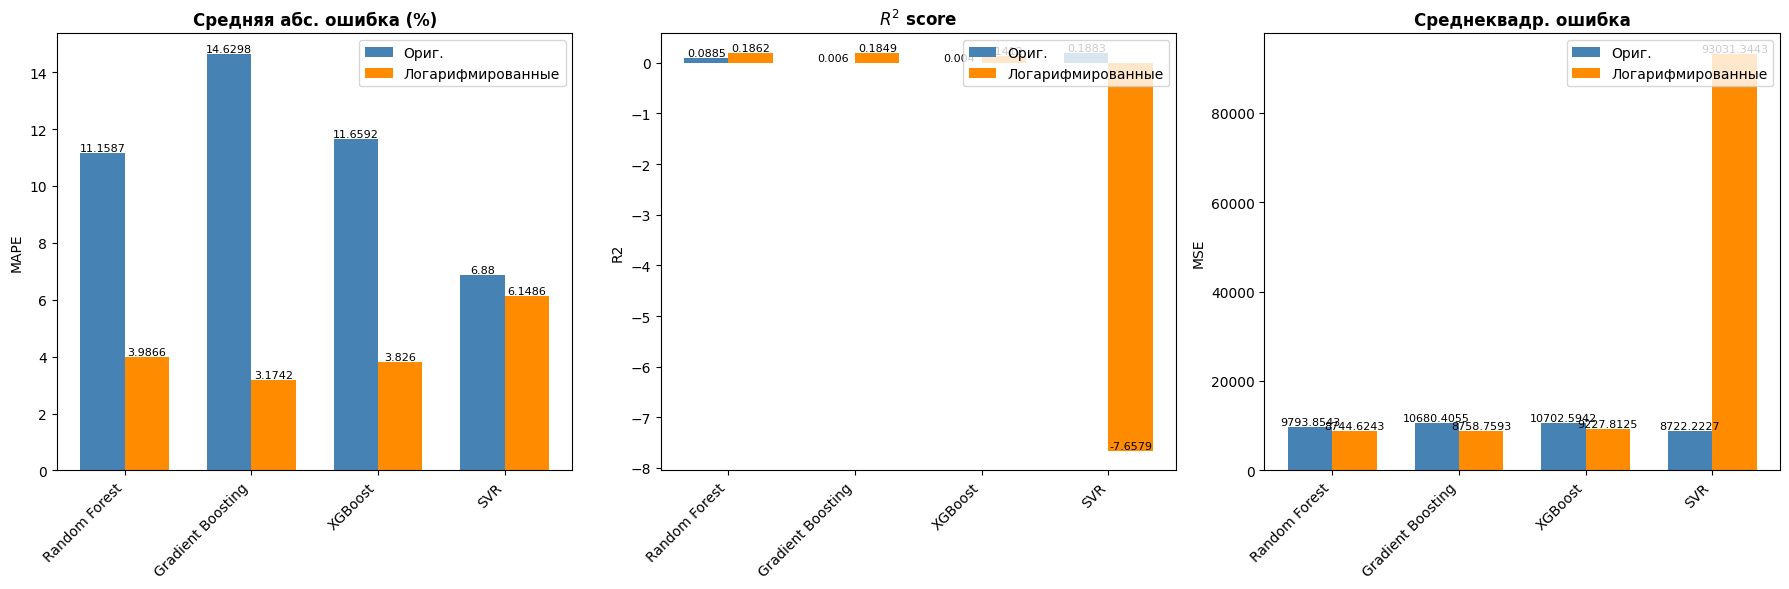

In [21]:
# Фильтруем модели с лог-преобразованиями и без
models_log = {name: data for name, data in results.items() if 'log' in name.lower()}
models_raw = {name: data for name, data in results.items() if 'log' not in name.lower()}

metrics = ['MAPE', 'R2', 'MSE']
titles = ['Средняя абс. ошибка (%)', '$R^2$ score', 'Среднеквадр. ошибка']

labels = list(models_raw.keys())
positions = np.arange(len(labels))
bar_width = 0.35  # Ширина одного столбика
fig, axes = plt.subplots(nrows=1, ncols=3, figsize=(18, 6))

for idx, metric in enumerate(metrics):
    ax = axes[idx]

    # Собираем значения метрики для обеих групп моделей
    raw_values = [models_raw[name][metric] for name in labels]
    log_values = [models_log.get(name + ' log-transformed', {}).get(metric, 0) for name in labels]

    bars_original = ax.bar(positions - bar_width/2, raw_values, bar_width, label='Ориг.', color='steelblue')
    bars_transformed = ax.bar(positions + bar_width/2, log_values, bar_width, label='Логарифмированные', color='darkorange')



    ax.set_ylabel(metric)
    ax.set_title(titles[idx], fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(labels, rotation=45, ha='right', fontsize=10)
    ax.legend(loc='upper right', frameon=True)

    def add_labels(bars):
        for bar in bars:
            value = round(bar.get_height(), 4)
            ax.text(bar.get_x() + bar.get_width()/2., bar.get_height(),
                   str(value), ha='center', va='bottom', fontsize=8)

    add_labels(bars_original)
    add_labels(bars_transformed)

plt.tight_layout()
plt.show()

СУммарно среди всех метрик лучший результат у Градиентного бустинга, поработаем с ним дальше

In [23]:
#Определим важность признаков
importances = grid_xgb.best_estimator_['xgb'].feature_importances_
importances

array([0.00167865, 0.        , 0.00221525, 0.00112788, 0.00375956,
       0.00727018, 0.00247957, 0.00499427, 0.        , 0.00229742,
       0.        , 0.00299299, 0.00385324, 0.00322537, 0.00814038,
       0.00330136, 0.00178773, 0.00261252, 0.02152624, 0.00671338,
       0.00294184, 0.00365705, 0.00833305, 0.01311163, 0.00393842,
       0.01306523, 0.00825887, 0.01950879, 0.00331539, 0.00312182,
       0.01223118, 0.00238048, 0.00399871, 0.01035353, 0.00153494,
       0.00620355, 0.00698382, 0.00639494, 0.00413098, 0.00573513,
       0.00440159, 0.00380539, 0.00158695, 0.00502328, 0.00305958,
       0.00312737, 0.00103985, 0.00309431, 0.00825859, 0.00932217,
       0.00161499, 0.0015795 , 0.00497734, 0.00061996, 0.00281183,
       0.00166051, 0.02498421, 0.00622265, 0.01908084, 0.00422724,
       0.00768   , 0.00564572, 0.00758386, 0.        , 0.00357284,
       0.00539702, 0.00896006, 0.00485269, 0.00584392, 0.        ,
       0.00025039, 0.00089878, 0.00095977, 0.0019148 , 0.00155

In [24]:
#нам нужно исключить признаки с нулевой важностью
feature_names = X.columns
# Порог для важности
threshold = 0.0

important_indices = np.where(importances > threshold)[0]
important_features = feature_names[important_indices]

feature_importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance': importances
})

#Выведем наиболее важные признаки
top_features = feature_importance_df.sort_values(by='Importance', ascending=False)
print(top_features.head(10))

                     Feature  Importance
101              VSA_EState6    0.062684
116               NumHDonors    0.054644
122                RingCount    0.052967
98               VSA_EState3    0.045356
103              VSA_EState8    0.037096
132                 fr_Ar_OH    0.036450
109  NumAliphaticCarbocycles    0.031142
56                 PEOE_VSA5    0.024984
18               BCUT2D_MWHI    0.021526
27                  BalabanJ    0.019509


# Итоговое обучение

Попробуем провести обучение на наиболее важных признаках

In [25]:
X_train_imp = X_train[important_features]
X_test_imp = X_test[important_features]

In [26]:
grid_xgb.best_params_

{'xgb__learning_rate': 0.05, 'xgb__n_estimators': 150}

Попробуем другие гиперпараметры

In [27]:
pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('model', GradientBoostingRegressor(random_state=42))
])

# Сетка гиперпараметров
param_grid = {
    'model__n_estimators': [200, 250, 300],
    'model__max_depth': [2, 3, 4, 5, 10],
    'model__learning_rate': [0.02, 0.05, 0.07]
}

# GridSearch
grid_search = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_r2_scorer,
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search.fit(X_train_imp, y_train_log)

Fitting 10 folds for each of 45 candidates, totalling 450 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.02, 0.05, 0.07],
                         'model__max_depth': [2, 3, 4, 5, 10],
                         'model__n_estimators': [200, 250, 300]},
             scoring=<function custom_r2_scorer at 0x7cd8d05e8ea0>, verbose=1)

In [28]:
results['Gradient Boosting filtered'] = {
    'MAPE': custom_mape_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
    'R2': custom_r2_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
    'MSE': custom_mse_scorer(grid_search.best_estimator_, X_test_imp, y_test_log),
}

Также попробуем более точно подобрать параметры и обучить модель на полных данных

In [29]:
# GridSearch
grid_search_full = GridSearchCV(
    estimator=pipeline,
    param_grid=param_grid,
    scoring=custom_r2_scorer,
    cv=10,
    n_jobs=-1,
    verbose=1
)

grid_search_full.fit(X_train, y_train_log)

Fitting 10 folds for each of 45 candidates, totalling 450 fits


GridSearchCV(cv=10,
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        GradientBoostingRegressor(random_state=42))]),
             n_jobs=-1,
             param_grid={'model__learning_rate': [0.02, 0.05, 0.07],
                         'model__max_depth': [2, 3, 4, 5, 10],
                         'model__n_estimators': [200, 250, 300]},
             scoring=<function custom_r2_scorer at 0x7cd8d05e8ea0>, verbose=1)

In [34]:
results['Gradient Boosting full tuned'] = {
    'MAPE': custom_mape_scorer(grid_search_full.best_estimator_, X_test, y_test_log),
    'R2': custom_r2_scorer(grid_search_full.best_estimator_, X_test, y_test_log),
    'MSE': custom_mse_scorer(grid_search_full.best_estimator_, X_test, y_test_log),
}

Визуализируем метрики всех вариантов модели Gradient Boosting

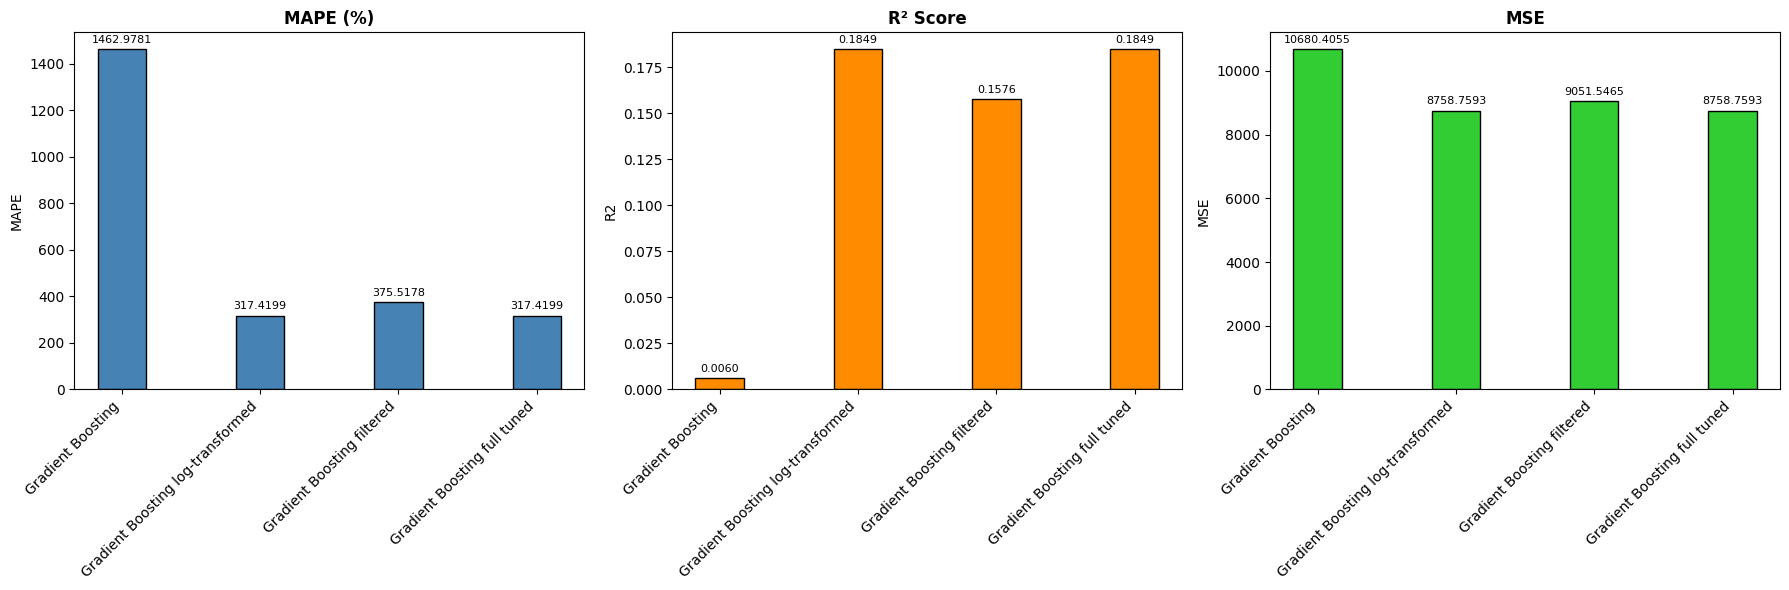

In [36]:
model_names = ['Gradient Boosting', 'Gradient Boosting log-transformed', 'Gradient Boosting filtered', 'Gradient Boosting full tuned']
metrics = ['MAPE', 'R2', 'MSE']
titles = ['MAPE (%)', 'R² Score', 'MSE']

bar_width = 0.35
positions = np.arange(len(model_names))
fig, axes = plt.subplots(ncols=3, figsize=(18, 6))


# Формируем гистограммы для каждой метрики
for idx, (ax, metric, title) in enumerate(zip(axes, metrics, titles)):
    colors = ['steelblue', 'darkorange', 'limegreen']
    values = [results[name].get(metric, 0) * 100 if metric == 'MAPE' else results[name].get(metric, 0) for name in model_names]

    bars = ax.bar(positions, values, bar_width, color=colors[idx % len(colors)], edgecolor='black')


    ax.set_ylabel(metric)
    ax.set_title(title, fontweight='bold')
    ax.set_xticks(positions)
    ax.set_xticklabels(model_names, rotation=45, ha='right', fontsize=10)

    def annotate_bars(bars):
        for bar in bars:
            height = bar.get_height()
            ax.annotate(f'{height:.4f}',
                        xy=(bar.get_x() + bar.get_width() / 2, height),
                        xytext=(0, 3),
                        textcoords="offset points",
                        ha='center', va='bottom', fontsize=8)

    annotate_bars(bars)

plt.tight_layout()
plt.show()